<a href="https://colab.research.google.com/github/dangchicong/hocsau/blob/main/Do_an.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
PHẦN 1: MÔ HÌNH MLP

In [ ]:
# Cài đặt thư viện kaggle
!pip install kaggle

# Upload file kaggle.json (lấy từ Settings trong hồ sơ Kaggle của bạn)
from google.colab import files
files.upload()

# Cấu hình thư mục chứa key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Lệnh tải dataset Fashion MNIST
!kaggle datasets download -d zalando-research/fashionmnist

# Giải nén
!unzip fashionmnist.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
100% 68.8M/68.8M [00:02<00:00, 34.0MB/s]

Archive:  fashionmnist.zip
  inflating: fashion-mnist_test.csv  
  inflating: fashion-mnist_train.csv  
  inflating: t10k-images-idx3-ubyte  
  inflating: t10k-labels-idx1-ubyte  
  inflating: train-images-idx3-ubyte  
  inflating: train-labels-idx1-ubyte  


Khai báo siêu tham số

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

# KHAI BÁO SIÊU THAM SỐ
learning_rate = 0.001  #[cite: 1, 6]
batch_size = 32        #[cite: 1]
epochs = 20           #[cite: 1]
optimizer_name = 'Adam' #
loss_function = 'sparse_categorical_crossentropy' #[cite: 1, 6]

# Define the model architecture (moved from cell 2NfBKp8Jnacs)
model = models.Sequential([
    # Lớp đầu vào: 784 nơ-ron tương ứng với kích thước ảnh[cite: 2]
    layers.Input(shape=(784,)),

    # Lớp ẩn thứ nhất: 256 nơ-ron + ReLU
    layers.Dense(256, activation='relu'),
    # Dropout 20% để chống Overfitting theo yêu cầu đề cương
    layers.Dropout(0.2),

    # Lớp ẩn thứ hai: 128 nơ-ron + ReLU
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Lớp đầu ra: 10 nơ-ron cho 10 loại quần áo + Softmax[cite: 2, 6]
    layers.Dense(10, activation='softmax')
])

# Áp dụng vào quá trình biên dịch mô hình
if optimizer_name == 'Adam':
    selected_optimizer = optimizers.Adam(learning_rate=learning_rate)
elif optimizer_name == 'SGD':
    selected_optimizer = optimizers.SGD(learning_rate=learning_rate)
else:
    # Fallback to Adam if optimizer_name is not recognized or default
    selected_optimizer = optimizers.Adam(learning_rate=learning_rate)

model.compile(
    optimizer=selected_optimizer,
    loss=loss_function,
    metrics=['accuracy']
)


Chuẩn hóa dữ liệu, Kết quả (60000, 784) xác nhận đã load thành công 60.000 mẫu dữ liệu, mỗi mẫu là một ảnh phẳng có 784 điểm ảnh. Với cấu hình RAM 16GB, chúng ta sẽ tiến hành xây dựng mô hình MLP theo đúng các yêu cầu  của đề cương đồ án


In [ ]:
import pandas as pd
import numpy as np

# 1. Đọc dữ liệu từ file CSV đã giải nén
train_data = pd.read_csv('fashion-mnist_train.csv')
test_data = pd.read_csv('fashion-mnist_test.csv')

# 2. Tách nhãn (y) và dữ liệu hình ảnh (X)
X_train = train_data.iloc[:, 1:].values
y_train = train_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values
y_test = test_data.iloc[:, 0].values

# 3. Chuẩn hóa dữ liệu về khoảng [0, 1]
# Đây là yêu cầu quan trọng để Gradient Descent chạy tốt trên CPU
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Kích thước tập train:", X_train.shape)
print("Dữ liệu đã sẵn sàng!")

Kích thước tập train: (60000, 784)
Dữ liệu đã sẵn sàng!


Xây dựng cấu trúc mạng MLP

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Khởi tạo mô hình tuần tự[cite: 2]
model = models.Sequential([
    # Lớp đầu vào: 784 nơ-ron tương ứng với kích thước ảnh[cite: 2]
    layers.Input(shape=(784,)),

    # Lớp ẩn thứ nhất: 256 nơ-ron + ReLU
    layers.Dense(256, activation='relu'),
    # Dropout 20% để chống Overfitting theo yêu cầu đề cương
    layers.Dropout(0.2),

    # Lớp ẩn thứ hai: 128 nơ-ron + ReLU
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Lớp đầu ra: 10 nơ-ron cho 10 loại quần áo + Softmax[cite: 2, 6]
    layers.Dense(10, activation='softmax')
])

# Biên dịch mô hình với các siêu tham số đã biện luận[cite: 1, 6]
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary() # Hiển thị bảng tóm tắt thông số để đưa vào báo cáo

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện mô hình

In [ ]:
# Bắt đầu huấn luyện[cite: 1, 2]
history = model.fit(
    X_train, y_train,
    epochs=20,            # Số lượt huấn luyện đã chọn
    batch_size=32,        # Kích thước lô phù hợp CPU[cite: 1]
    validation_split=0.2, # Tách 20% để kiểm định (Validation)[cite: 6]
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7951 - loss: 0.5640 - val_accuracy: 0.8481 - val_loss: 0.4095
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8454 - loss: 0.4217 - val_accuracy: 0.8641 - val_loss: 0.3748
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8583 - loss: 0.3852 - val_accuracy: 0.8730 - val_loss: 0.3540
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8665 - loss: 0.3628 - val_accuracy: 0.8733 - val_loss: 0.3585
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8714 - loss: 0.3498 - val_accuracy: 0.8773 - val_loss: 0.3398
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8774 - loss: 0.3335 - val_accuracy: 0.8756 - val_loss: 0.3404
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8796 - loss: 0.3232 - val_accuracy: 0.8787 - val_loss: 0.3425
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8842 - loss: 0

Vẽ biểu đồ Accuracy và Loss

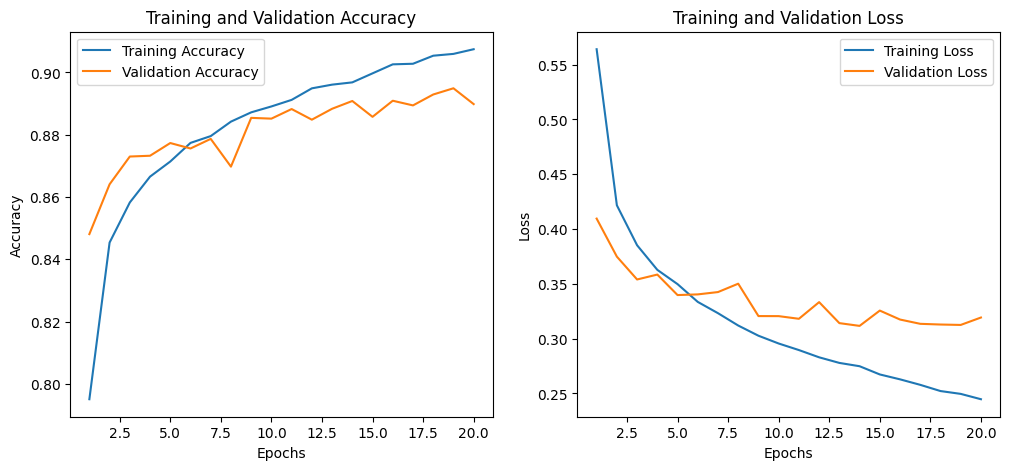

In [ ]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ biến history[cite: 1]
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Vẽ biểu đồ Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Vẽ biểu đồ Loss Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Đánh giá trên tập Test

In [ ]:
# Chuyển sang chế độ suy luận và đánh giá[cite: 6]
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Độ chính xác trên tập Test: {test_acc*100:.2f}%")

Độ chính xác trên tập Test: 89.08%


Xuất các chỉ số đánh giá chuyên sâu

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1000
           1       0.99      0.98      0.98      1000
           2       0.87      0.78      0.82      1000
           3       0.88      0.93      0.90      1000
           4       0.76      0.92      0.83      1000
           5       0.98      0.95      0.96      1000
           6       0.78      0.61      0.68      1000
           7       0.91      0.97      0.94      1000
           8       0.96      0.98      0.97      1000
           9       0.97      0.94      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



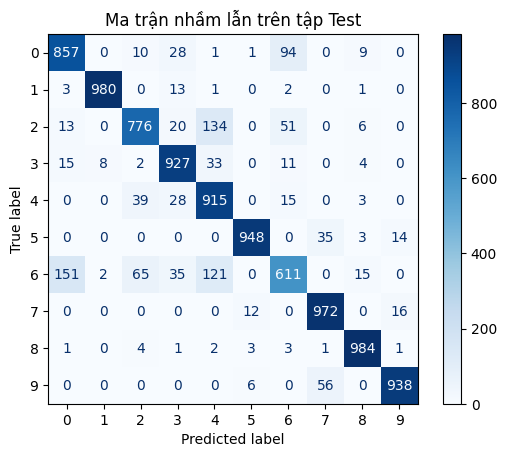

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Dự đoán nhãn trên tập test (Chế độ suy luận)
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 1. Tính Precision, Recall, F1-score[cite: 6]
print("Báo cáo phân loại chi tiết:")
print(classification_report(y_test, y_pred))

# 2. Vẽ Ma trận nhầm lẫn (Confusion Matrix)[cite: 6]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Ma trận nhầm lẫn trên tập Test')
plt.show()

In [ ]:
import pandas as pd

# Trích xuất dữ liệu Accuracy và Val_Accuracy vào một bảng (DataFrame)
history_df = pd.DataFrame(history.history)

# Chỉ lấy cột Accuracy và Val_Accuracy để phục vụ phân tích Overfitting
accuracy_table = history_df[['accuracy', 'val_accuracy']]

# Đổi tên cột cho trang trọng trong báo cáo
accuracy_table.columns = ['Training Accuracy', 'Validation Accuracy']

# Hiển thị bảng kết quả
print("BẢNG TỔNG HỢP ĐỘ CHÍNH XÁC QUA 20 EPOCHS")
print(accuracy_table)

BẢNG TỔNG HỢP ĐỘ CHÍNH XÁC QUA 20 EPOCHS
    Training Accuracy  Validation Accuracy
0            0.795062             0.848083
1            0.845375             0.864083
2            0.858250             0.873000
3            0.866542             0.873250
4            0.871396             0.877333
5            0.877375             0.875583
6            0.879562             0.878667
7            0.884208             0.869750
8            0.887187             0.885417
9            0.889083             0.885167
10           0.891187             0.888250
11           0.894896             0.884833
12           0.896083             0.888333
13           0.896812             0.890833
14           0.899708             0.885750
15           0.902604             0.890917
16           0.902792             0.889417
17           0.905375             0.892917
18           0.905958             0.894917
19           0.907458             0.889833


In [ ]:
import pandas as pd

# Giả sử 'history' là biến lưu kết quả từ lệnh model.fit() của bài MLP
# Tạo bảng dữ liệu từ lịch sử huấn luyện
accuracy_table = pd.DataFrame({
    'Training Accuracy': history.history['accuracy'],
    'Validation Accuracy': history.history['val_accuracy'],
    'Training Loss': history.history['loss'],
    'Validation Loss': history.history['val_loss']
})

# Lưu bảng kết quả thành file CSV để nộp kèm đồ án
accuracy_table.to_csv('mlp_training_history.csv', index_label='Epoch')

# Hiển thị 5 dòng cuối cùng để lấy số liệu báo cáo
print("DỮ LIỆU HUẤN LUYỆN MLP (5 EPOCH CUỐI)")
print(accuracy_table.tail())

DỮ LIỆU HUẤN LUYỆN MLP (5 EPOCH CUỐI)
    Training Accuracy  Validation Accuracy  Training Loss  Validation Loss
15           0.902604             0.890917       0.262911         0.317456
16           0.902792             0.889417       0.257895         0.313553
17           0.905375             0.892917       0.252232         0.312910
18           0.905958             0.894917       0.249647         0.312537
19           0.907458             0.889833       0.244777         0.319297


## PHẦN 2: MÔ HÌNH HỒI QUY _ REGRESSION

Làm sach bộ nhớ

In [ ]:
import tensorflow as tf
# Xóa các mô hình và tham số cũ trong bộ nhớ Keras
tf.keras.backend.clear_session()
print("Đã dọn dẹp bộ nhớ, sẵn sàng cho mô hình Hồi quy.")

Đã dọn dẹp bộ nhớ, sẵn sàng cho mô hình Hồi quy.


Chuẩn bị dữ liệu Hồi quy

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os

# Ensure the 'House Prices' dataset is available
# Download the dataset if not present. Assumes kaggle.json is already configured.
if not os.path.exists('train.csv'):
    print("Downloading 'House Prices' dataset...")
    !kaggle competitions download -c house-prices-advanced-regression-techniques
    !unzip -o house-prices-advanced-regression-techniques.zip
    print("'House Prices' dataset downloaded and unzipped.")
else:
    print("'train.csv' already exists. Skipping download.")

# 1. Load dữ liệu
df_house = pd.read_csv('train.csv')

# 2. Chọn biến: Diện tích sàn (GrLivArea) để dự báo Giá nhà (SalePrice)
X = df_house[['GrLivArea']].values
y = df_house['SalePrice'].values.reshape(-1, 1)

# 3. Chuẩn hóa dữ liệu (Z-score Scaling)
sc_x, sc_y = StandardScaler(), StandardScaler()
X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y)

# 4. Chia dữ liệu 80/20
X_train, X_val, y_train, y_val = train_test_split(X_std, y_std, test_size=0.2, random_state=42)

100% 199k/199k [00:00<00:00, 122MB/s]

Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
'House Prices' dataset downloaded and unzipped.


KHAI BÁO SIÊU THAM SỐ

In [ ]:
# --- BƯỚC KHAI BÁO SIÊU THAM SỐ (HYPERPARAMETERS) ---
LEARNING_RATE = 0.01   # Tốc độ học
EPOCHS = 100           # Số vòng lặp
BATCH_SIZE = 32        # Kích thước lô dữ liệu
OPTIMIZER_NAME = 'SGD' # Thuật toán tối ưu (Stochastic Gradient Descent)
LOSS_FUNCTION = 'mse'  # Hàm mất mát (Mean Squared Error cho Hồi quy)

print(f"Đã xác lập siêu tham số: LR={LEARNING_RATE}, Epochs={EPOCHS}")

Đã xác lập siêu tham số: LR=0.01, Epochs=100


Xây dựng và Huấn luyện mô hình

In [ ]:
from tensorflow.keras import models, layers

# Khởi tạo mô hình tuần tự
model_reg = models.Sequential([
    layers.Dense(1, input_shape=(1,)) # 1 đầu vào (diện tích), 1 đầu ra (giá nhà)
])

# Hiển thị cấu trúc để chụp ảnh đưa vào báo cáo
model_reg.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import optimizers

# Sử dụng các biến siêu tham số từ ô Bước A
model_reg.compile(
    optimizer=optimizers.SGD(learning_rate=LEARNING_RATE),
    loss=LOSS_FUNCTION
)
print("Đã biên dịch mô hình với các siêu tham số từ Bước A.")

Đã biên dịch mô hình với các siêu tham số từ Bước A.


In [ ]:
# Quá trình huấn luyện sử dụng các biến từ Bước A
history_reg = model_reg.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3.2524 - val_loss: 2.0681
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.1116 - val_loss: 0.9607
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.6283 - val_loss: 0.6794
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.5232 - val_loss: 0.5916
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4963 - val_loss: 0.5560
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4906 - val_loss: 0.5460
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4906 - val_loss: 0.5458
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4906 - val_loss: 0.5422
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4900 - val_loss: 0.5427
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4903 - val_loss: 0.5410
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4900 - val_loss: 0.5429
Epoch 12/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 

Tính các chỉ số MAE, MSE, RMSE

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
print(f"MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

MAE: 0.4829, MSE: 0.5463, RMSE: 0.7391


Xuất chỉ số và Biểu đồ

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
--- KẾT QUẢ CHO BÁO CÁO ---
Chỉ số R2 Score: 0.5508


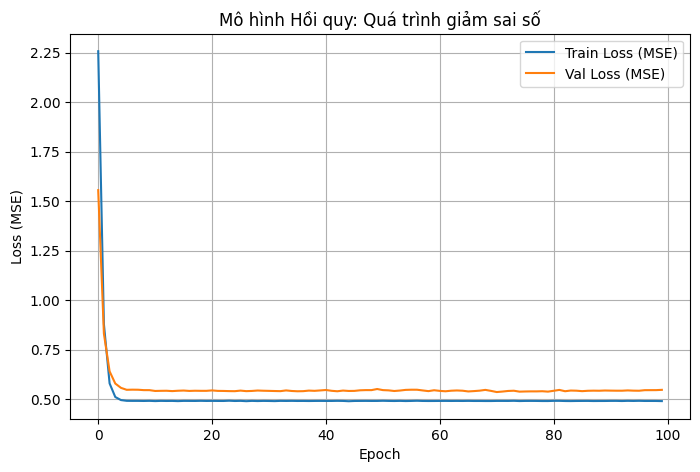

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Dự đoán thử nghiệm
y_pred = model_reg.predict(X_val)

# Tính R2 Score (mục tiêu > 0.5)
r2 = r2_score(y_val, y_pred)
print(f"--- KẾT QUẢ CHO BÁO CÁO ---")
print(f"Chỉ số R2 Score: {r2:.4f}")

# Vẽ đồ thị Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(history_reg.history['loss'], label='Train Loss (MSE)')
plt.plot(history_reg.history['val_loss'], label='Val Loss (MSE)')
plt.title('Mô hình Hồi quy: Quá trình giảm sai số')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

PHẦN 3: MÔ HÌNH CNN

In [4]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [5]:
from tensorflow.keras.datasets import fashion_mnist

# Tải dữ liệu Fashion MNIST
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Khai báo siêu tham số

In [25]:
from tensorflow import keras
from tensorflow.keras import layers

# --- BƯỚC KHAI BÁO SIÊU THAM SỐ CHO MÔ HÌNH CNN ---
# 1. Thông số huấn luyện
CNN_LEARNING_RATE = 0.001   # Adam thường dùng 0.001 thay vì 0.01 như SGD
CNN_EPOCHS = 20            # Duy trì 20 để so sánh công bằng với MLP
CNN_BATCH_SIZE = 64        # Tăng lên 64 để tận dụng tốt RAM 16GB

# 2. Thông số kiến trúc mạng (Architecture)
NUM_FILTERS = 32           # Số lượng bộ lọc ở lớp Convolution đầu tiên
KERNEL_SIZE = (3, 3)       # Kích thước bộ lọc tiêu chuẩn cho ảnh 28x28
POOL_SIZE = (2, 2)         # Kích thước cửa sổ giảm mẫu (Max Pooling)
NUM_CLASSES = 10           # 10 loại quần áo trong Fashion MNIST

# 3. Các hàm mục tiêu
CNN_OPTIMIZER = 'adam'     # Adam hội tụ nhanh và ổn định hơn cho CNN
CNN_LOSS = 'sparse_categorical_crossentropy'
CNN_METRICS = ['accuracy']
print(f"Đã thiết lập siêu tham số cho CNN: LR={CNN_LEARNING_RATE}, Filters={NUM_FILTERS}")

# Xây dựng mô hình sử dụng các biến đã khai báo
model_cnn = keras.Sequential([
    layers.Conv2D(filters=NUM_FILTERS, kernel_size=KERNEL_SIZE, activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=POOL_SIZE),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Biên dịch với siêu tham số
model_cnn.compile(optimizer=CNN_OPTIMIZER, loss=CNN_LOSS, metrics=CNN_METRICS)

Đã thiết lập siêu tham số cho CNN: LR=0.001, Filters=32


**Chuyển đổi và tiền xử lý dữ liệu cho phù hợp với CNN.**

Mặc dù bộ dữ liệu Fashion MNIST đã được tiền xử lý sạch (không có dữ liệu trống hay nhãn sai), cần thực hiện bước Min-Max Scaling để đưa dải pixel từ  [0,255]  về  [0,1] . Việc này không nhằm mục đích sửa lỗi dữ liệu mà là một yêu cầu kỹ thuật bắt buộc để tối ưu hóa bề mặt hàm mất mát, giúp thuật toán Adam hội tụ nhanh hơn và tránh hiện tượng bão hòa đạo hàm trên kiến trúc CNN sâu.

In [26]:
from tensorflow.keras.datasets import fashion_mnist

# Ensure X_train and X_test are loaded and reshaped for CNN, if not already
# This makes the cell robust against out-of-order execution or kernel resets
if 'X_train' not in locals() or 'X_train' not in globals() or X_train.ndim != 4:
    print("Loading and reshaping Fashion MNIST data...")
    (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)
print(f"Cấu trúc dữ liệu mới cho CNN: {X_train.shape}")
# Ensure data type is float32 for normalization
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# If data is not normalized (max value is still 255), then normalize it
# This prevents double-normalization if previous cells already did it
if X_train.max() > 1.0:
    print(f"Giá trị pixel trước chuẩn hóa: Max={X_train.max()}, Min={X_train.min()}")
    X_train = X_train / 255.0
    X_test = X_test / 255.0
    print(f"Giá trị pixel sau chuẩn hóa: Max={X_train.max()}, Min={X_train.min()}")
else:
    print("Dữ liệu đã được chuẩn hóa.")
    print(f"Giá trị pixel: Max={X_train.max()}, Min={X_train.min()}")

Cấu trúc dữ liệu mới cho CNN: (60000, 28, 28, 1)
Dữ liệu đã được chuẩn hóa.
Giá trị pixel: Max=1.0, Min=0.0


Thiết kế mô hình CNN

In [32]:
from tensorflow.keras import layers, models

def build_cnn_3_layers():
    model = models.Sequential([
        # Khối 1: Trích xuất đặc trưng sơ cấp
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv_1'),
        layers.MaxPooling2D((2, 2), name='pool_1'),

        # Khối 2: Trích xuất đặc trưng trung cấp
        layers.Conv2D(64, (3, 3), activation='relu', name='conv_2'),
        layers.MaxPooling2D((2, 2), name='pool_2'),

        # Khối 3: Trích xuất đặc trưng cao cấp
        layers.Conv2D(128, (3, 3), activation='relu', name='conv_3'),
        # Lưu ý: Không cần Pool ở đây vì kích thước đã đủ nhỏ (3x3)

        # Khối Phân loại (Dense Layers)
        layers.Flatten(),
        layers.Dense(128, activation='relu', name='fc_1'),
        layers.Dropout(0.3), # Chống quá khớp cho mạng sâu
        layers.Dense(10, activation='softmax', name='output')
    ])
    return model

model_cnn = build_cnn_3_layers()
model_cnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện

In [11]:
model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Huấn luyện
history_3_layers = model_cnn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 65ms/step - accuracy: 0.8025 - loss: 0.5460 - val_accuracy: 0.8620 - val_loss: 0.3702
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 68ms/step - accuracy: 0.8767 - loss: 0.3394 - val_accuracy: 0.8897 - val_loss: 0.3049
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.8930 - loss: 0.2909 - val_accuracy: 0.8926 - val_loss: 0.2913
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.9049 - loss: 0.2616 - val_accuracy: 0.8991 - val_loss: 0.2793
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.9140 - loss: 0.2344 - val_accuracy: 0.9072 - val_loss: 0.2584
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 66ms/step - accuracy: 0.9208 - loss: 0.2168 - val_accuracy: 0.9120 - val_loss: 0.2487
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.9272 - loss: 0.1970 - val_accuracy: 0.9128 - val_loss: 0.2459
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.9352 - loss: 0.1792 - 

In [33]:
import tensorflow as tf

# Bước 1: Trích xuất danh sách tất cả các lớp Conv2D trong mô hình của bạn
conv_layers = [layer.output for layer in model_cnn.layers if isinstance(layer, tf.keras.layers.Conv2D)]

# Bước 2: Tạo mô hình trích xuất (feature_extractor)
# Nó sẽ lấy đầu vào là ảnh gốc và đầu ra là kết quả của các lớp Conv2D
feature_extractor = tf.keras.Model(inputs=model_cnn.inputs, outputs=conv_layers)

print(f"Đã tạo xong feature_extractor với {len(conv_layers)} lớp tích chập.")

Đã tạo xong feature_extractor với 3 lớp tích chập.


Vẽ biểu đồ

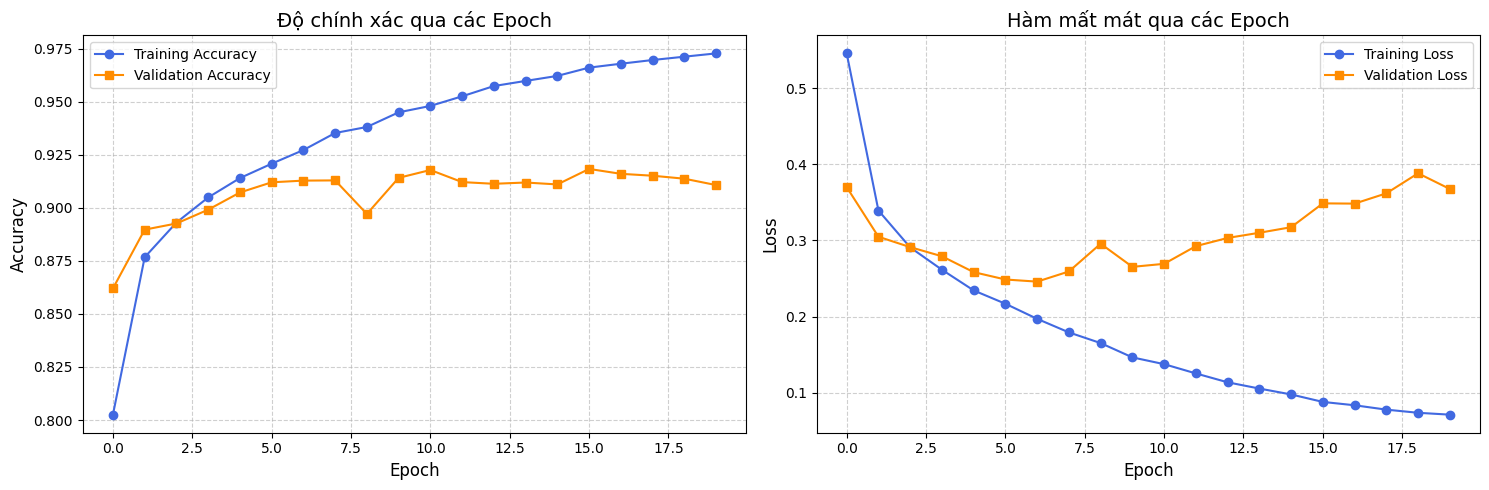

In [13]:
import matplotlib.pyplot as plt

# Thiết kế khung ảnh gồm 2 biểu đồ con
plt.figure(figsize=(15, 5))

# 1. Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_3_layers.history['accuracy'], label='Training Accuracy', marker='o', color='royalblue')
plt.plot(history_3_layers.history['val_accuracy'], label='Validation Accuracy', marker='s', color='darkorange')
plt.title('Độ chính xác qua các Epoch', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(history_3_layers.history['loss'], label='Training Loss', marker='o', color='royalblue')
plt.plot(history_3_layers.history['val_loss'], label='Validation Loss', marker='s', color='darkorange')
plt.title('Hàm mất mát qua các Epoch', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('performance_charts.png', dpi=300) # Lưu ảnh chất lượng cao cho báo cáo
plt.show()

Về biểu đồ Accuracy:Đường Accuracy trên tập huấn luyện (Training) tăng trưởng ổn định và tiệm cận mức 97%. Tuy nhiên, đường Validation bắt đầu đi ngang từ Epoch 15 quanh mức 91%. Khoảng cách này cho thấy mô hình có dấu hiệu Overfitting nhẹ.

Hàm Loss giảm sâu và ổn định, chứng tỏ bộ tối ưu Adam hoạt động hiệu quả trên máy tính cấu hình i7



TRỰC QUAN HÓA FEATURE MAPS

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


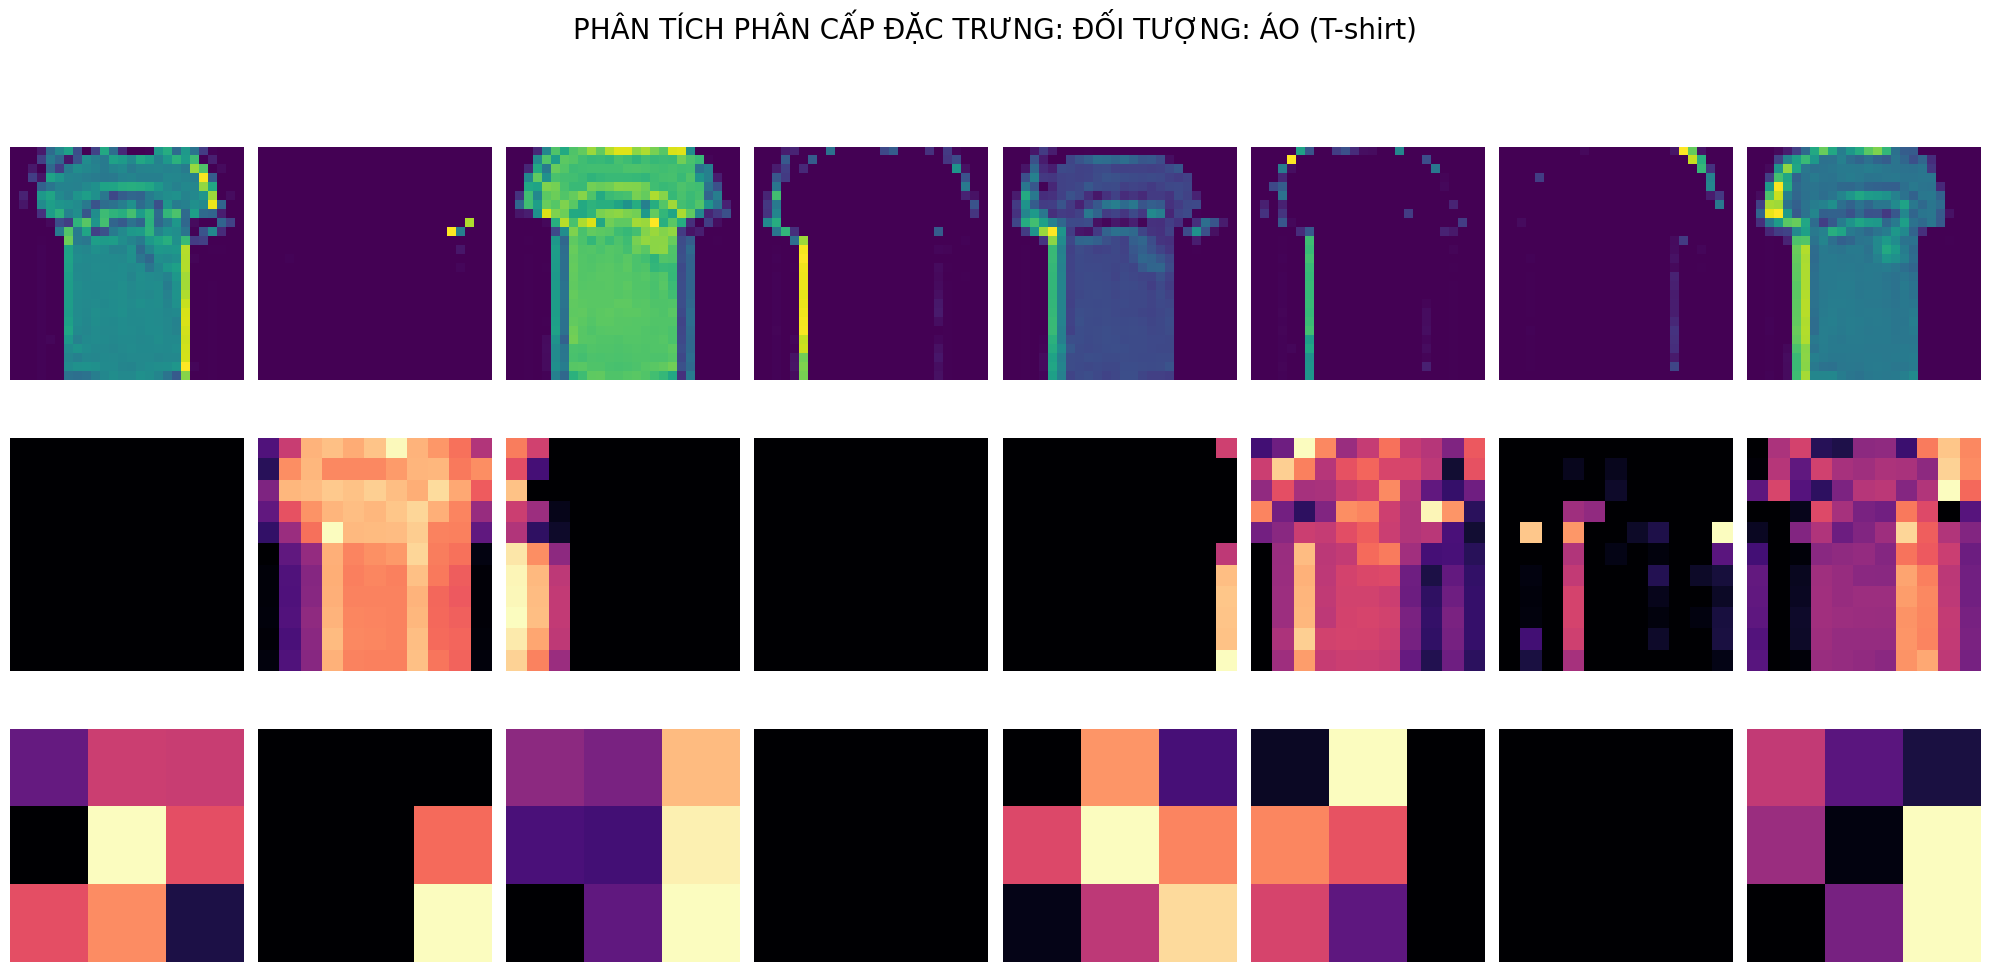

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


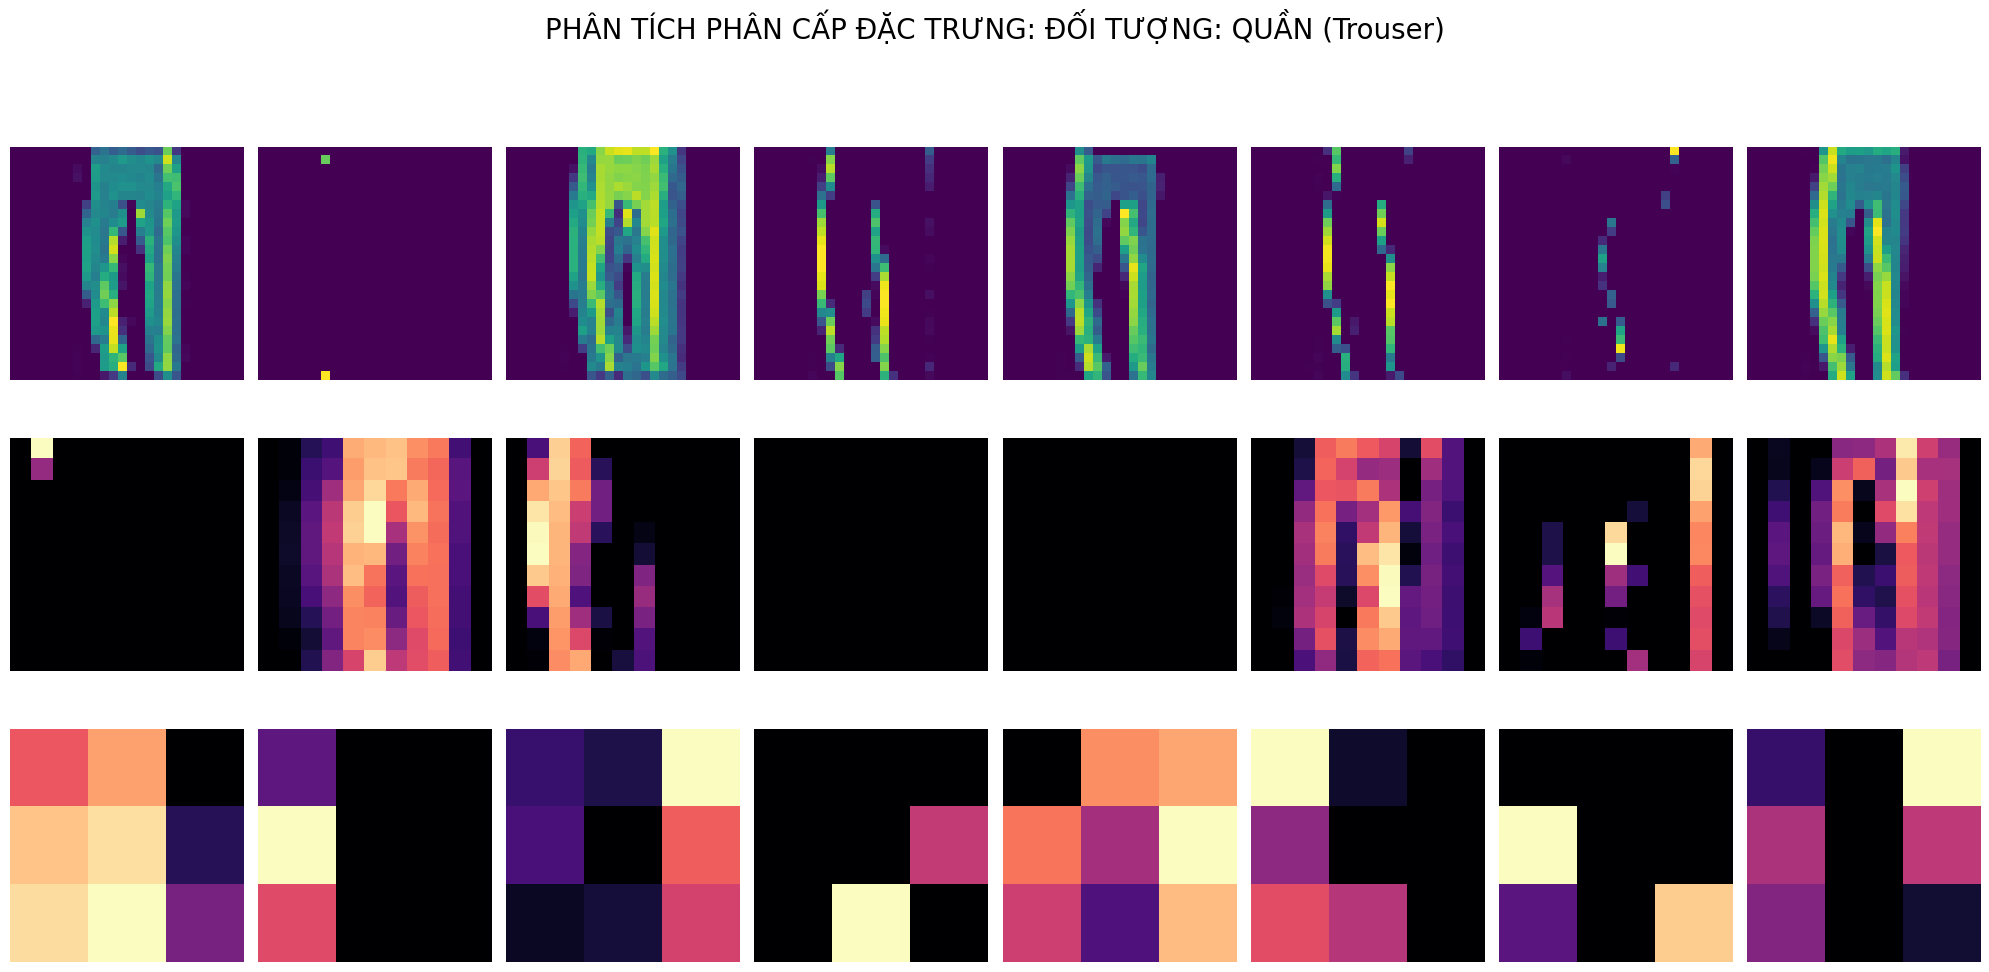

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


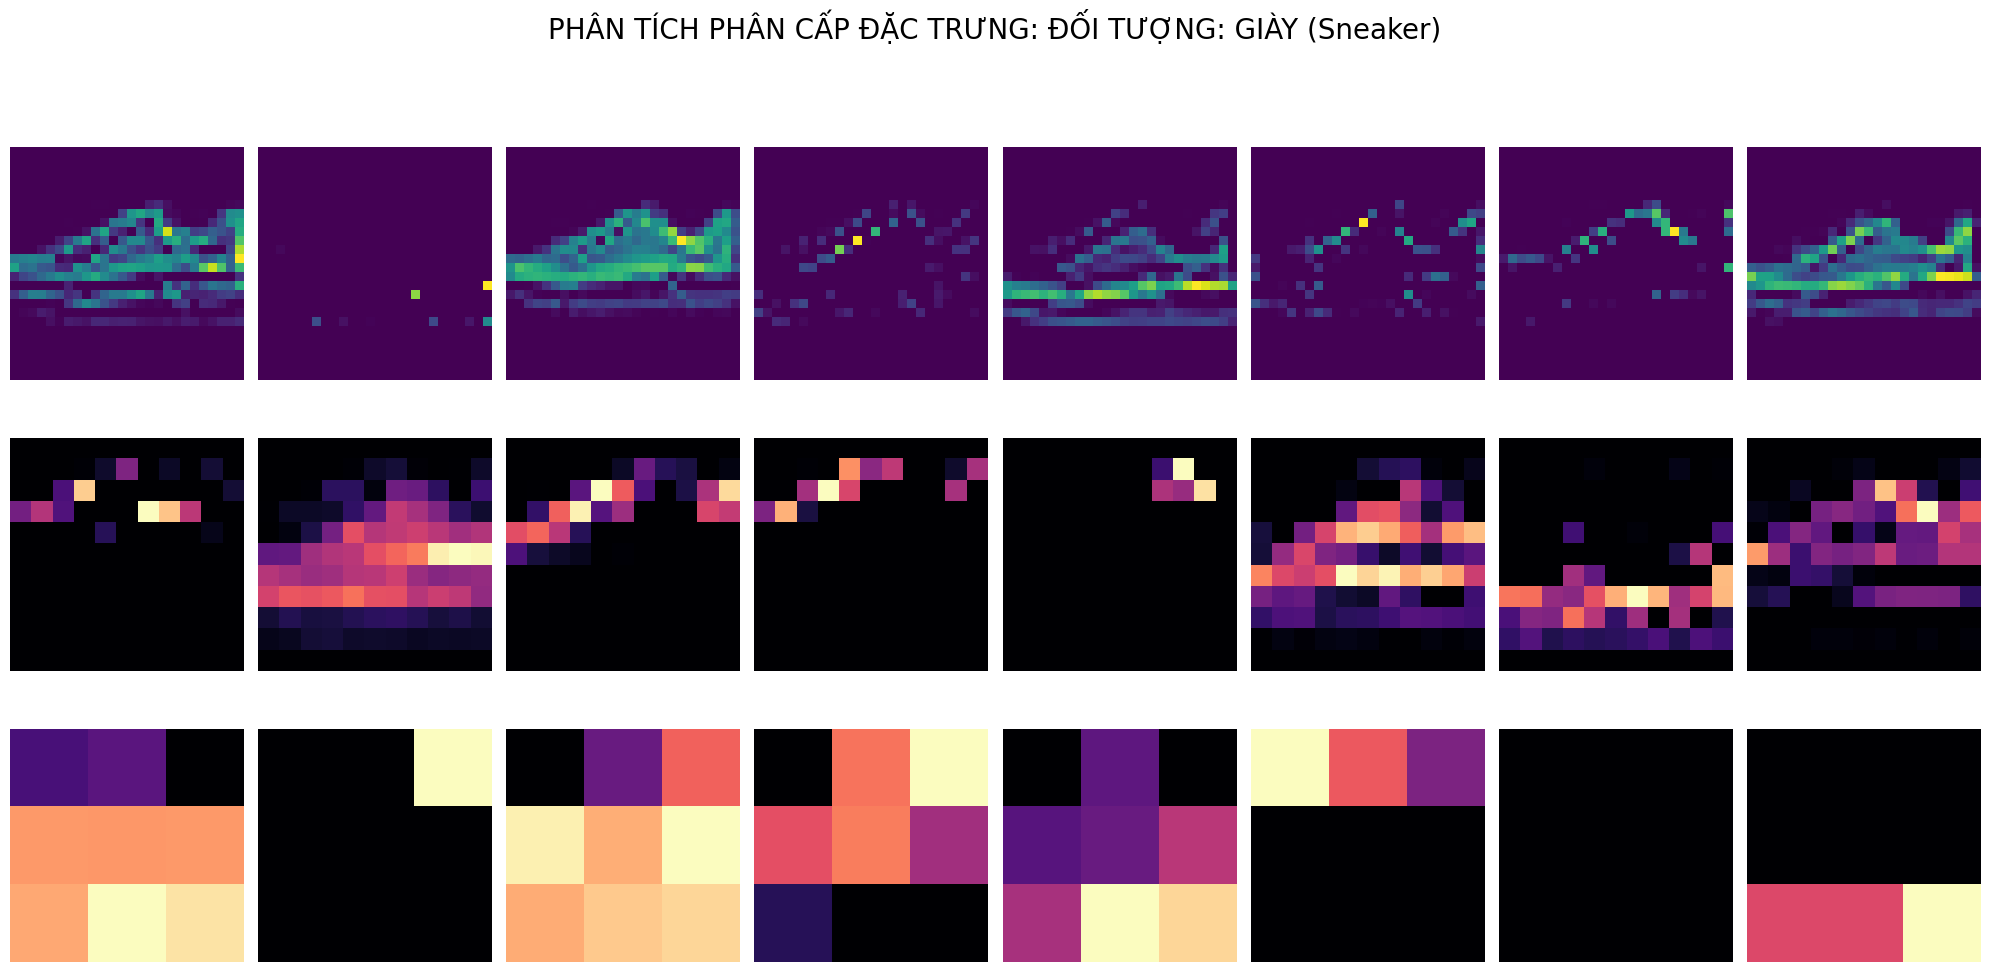

In [36]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# 1. Chuẩn bị model trích xuất 3 lớp (Nông, Trung, Sâu)
# Đảm bảo model_cnn của bạn có ít nhất 5 layers theo kiến trúc đã build
feature_extractor = tf.keras.Model(
    inputs=model_cnn.inputs,
    outputs=[model_cnn.layers[0].output,  # Lớp nông (Conv 1)
             model_cnn.layers[2].output,  # Lớp trung (Conv 2)
             model_cnn.layers[4].output]  # Lớp sâu (Conv 3)
)

def visualize_hierarchy(target_label, title_obj):
    # Tìm ảnh đúng loại yêu cầu
    indices = np.where(y_test == target_label)[0]
    img = X_test[indices[0]:indices[0]+1]

    activations = feature_extractor.predict(img)
    fig, axes = plt.subplots(3, 8, figsize=(20, 10))
    levels = ['NÔNG (Cạnh/Nét)', 'TRUNG (Hình khối)', 'SÂU (Ngữ nghĩa)']

    for r in range(3):
        layer_activation = activations[r]
        for c in range(8):
            ax = axes[r, c]
            # Kiểm tra số chiều để tránh lỗi IndexError
            if len(layer_activation.shape) == 4:
                # Nếu là lớp Conv (4 chiều: Batch, H, W, Filters)
                ax.imshow(layer_activation[0, :, :, c], cmap='viridis' if r==0 else 'magma')
            else:
                # Nếu lỡ trỏ nhầm vào lớp Dense/Flatten (2 chiều)
                ax.text(0.5, 0.5, 'Dense Layer', ha='center')

            ax.axis('off')
            if c == 0:
                ax.set_ylabel(levels[r], rotation=90, size='large', labelpad=20, fontweight='bold')

    plt.suptitle(f"PHÂN TÍCH PHÂN CẤP ĐẶC TRƯNG: {title_obj}", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# 2. Thực thi cho 3 đối tượng để đảm bảo tính nhất quán (Logic Đồ án)
visualize_hierarchy(0, "ĐỐI TƯỢNG: ÁO (T-shirt)")
visualize_hierarchy(1, "ĐỐI TƯỢNG: QUẦN (Trouser)")
visualize_hierarchy(7, "ĐỐI TƯỢNG: GIÀY (Sneaker)")